In [17]:
import pandas as pd
import numpy as np

data = {
    'Size_sqft': [800, 1000, 1200, 1400, 1600, 1800, 2000, 2200],
    'Bedrooms':  [2,   2,    3,    3,    4,    4,    5,    5],
    'Age_years':[15,  12,   10,    8,    6,    5,    3,    2],
    'City':     ['A','A','B','B','C','C','D','D'],   
    'Owner_name':['x','y','z','p','q','r','s','t'], 
    'Price_lakh':[35, 42,   50,   58,   67,   75,   85,   95]
}

df = pd.DataFrame(data)
df

,Size_sqft,Bedrooms,Age_years,City,Owner_name,Price_lakh
0,800,2,15,A,x,35
1,1000,2,12,A,y,42
2,1200,3,10,B,z,50
3,1400,3,8,B,p,58
4,1600,4,6,C,q,67
5,1800,4,5,C,r,75
6,2000,5,3,D,s,85
7,2200,5,2,D,t,95


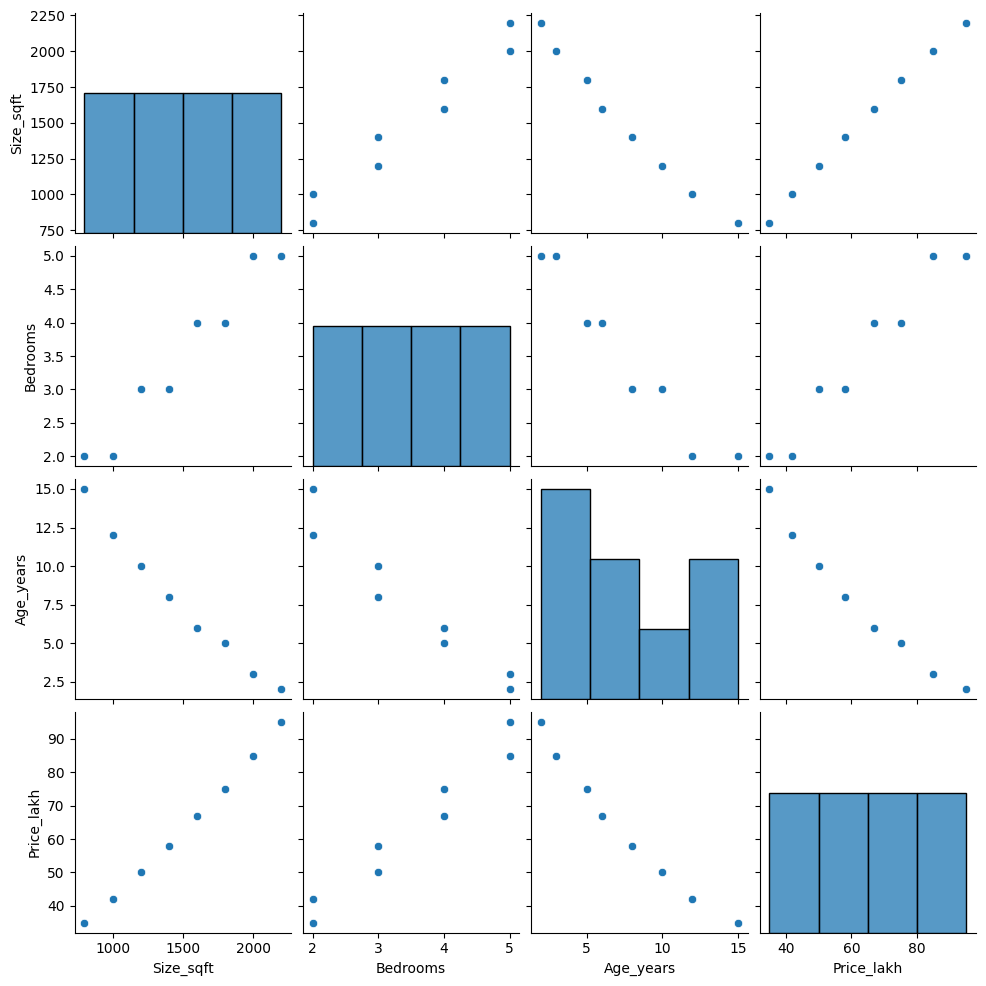

In [18]:
import seaborn as sns

sns.pairplot(df)

<Axes: xlabel='Size_sqft', ylabel='Price_lakh'>

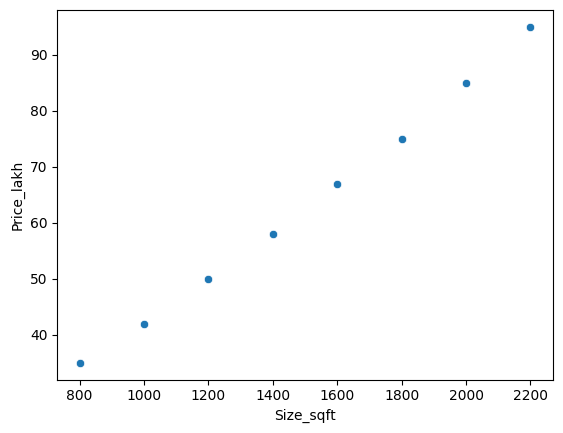

In [19]:
sns.scatterplot(x='Size_sqft', y='Price_lakh', data=df)

In [20]:
X = df[['Size_sqft', 'Bedrooms', 'Age_years']] 
y = df['Price_lakh']                            

In [21]:
X

,Size_sqft,Bedrooms,Age_years
0,800,2,15
1,1000,2,12
2,1200,3,10
3,1400,3,8
4,1600,4,6
5,1800,4,5
6,2000,5,3
7,2200,5,2


In [22]:
y

0    35
1    42
2    50
3    58
4    67
5    75
6    85
7    95
Name: Price_lakh, dtype: int64

In [23]:
X.shape

(8, 3)

In [24]:
y.shape

(8,)

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [28]:
# y_test

In [29]:
y_pred = model.predict(X_test_scaled)
y_pred

array([41.35294118, 76.5       ])

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 1.07352941176471
RMSE: 1.1551374639209129
R2  : 0.9950988335700509


In [31]:
new_house = pd.DataFrame({
    'Size_sqft': [1600],
    'Bedrooms':  [4],
    'Age_years': [6]
})

new_house_scaled = scaler.transform(new_house)
prediction = model.predict(new_house_scaled)

prediction

array([66.77941176])